In [17]:
##############################################
##############################################
### TO GET ACCESS TO FILE IN GOOGLE COLAB ###
##############################################
##############################################

# To get access to the data files from github in Google Colab
#!git clone https://github.com/math869c/graph_representation_st457.git

# set the folder to get access to the data
#import os
#os.chdir('/content') # to avoid error if rerun
#os.chdir('./graph_representation_st457')

In [2]:
# installation of Pytorch Geometric. This may take up to 30 minutes!!!

#!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
#!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
#!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

# install DGL
#!pip install dgl
#!pip install numpy==1.26.4

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torch.optim as optim
import json

# load from other folders
from helper_functions import *
from model_classes import *

2026-04-19 11:02:39.447037: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Load data for GAT

In [ ]:
# Stock prices
open_prices_interp = pd.read_csv('data_folder/open_prices_interp.csv', index_col=0)
# into numpy
x = open_prices_interp.to_numpy()
tickers_with_data = open_prices_interp.columns

# Load graph data
with open("data_folder/firm_industry.json", "r") as f:
    firm_industry_dict = json.load(f)
A = np.load("data_folder/adjacency_matrix.npy")
adj_matrix = torch.tensor(A, dtype=torch.float32)

# make training data
batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(x, 
                                                                                                        batch_size =batch_size, 
                                                                                                        flatten_data = False, # Should be True for LSTM and GTC and False for GAT
                                                                                                        flatten_time_features=True # Should be False for LSTM and GTC and True for GAT
                                                                                                        )  

# Train GAT model

In [ ]:
# GAT model in the current format cannot handle float values and need binary values. So I have set a threshold for correlation 
corr = adj_matrix[:, :, 2]
corr_bin = (corr.abs() > 0.3).float()
corr_bin.fill_diagonal_(1.0)

dict_adj_matrices = {'corre':     {'MSE':0, 'model':np.empty, 'matrix':corr_bin.unsqueeze(-1), 'pred':np.empty},
                     'sector':    {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,0].unsqueeze(-1), 'pred':np.empty},
                     'industry':  {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,1].unsqueeze(-1), 'pred':np.empty},
                     'everything':{'MSE':0, 'model':np.empty, 'matrix':torch.stack([adj_matrix[:, :, 0], adj_matrix[:, :, 1], corr_bin], dim=-1),               'pred':np.empty} }

for key in dict_adj_matrices.keys():
  print(f'Doing model: {key}')
  A_loop = dict_adj_matrices[key]['matrix']
  K_num_relations = A_loop.shape[-1] # This will be 1 for single relations, and 3 for 'everything'

  model_GAT = GAT(c_in=40, c_hidden=32, num_relations= K_num_relations, c_out=1, num_heads=4)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model_GAT.parameters(), lr=1e-3)

  num_epochs = 50 # My general observation is that it takes many more epochs to train this model
  train_losses = []
  val_losses = []

  for epoch in range(num_epochs):
      train_loss = train_one_epoch_GAT(model_GAT, train_loader, A_loop, optimizer, criterion)
      val_loss = evaluate_GAT(model_GAT, val_loader, A_loop, criterion)
      print(f"Epoch {epoch+1:03d} | train loss {train_loss:.6f} | val loss {val_loss:.6f}")

  dict_adj_matrices[key]['model'] = model_GAT
  pred_test_GAT = predict_GAT(model_GAT, test_loader, A_loop)

  dict_adj_matrices[key]['pred'] = pred_test_GAT

  dict_adj_matrices[key]['MSE'] = np.mean((y_test-pred_test_GAT.numpy())**2,axis=0)

  

Doing model: corre
Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch 020 | train loss 1.000706 | val loss 4.260304
Doing model: sector
Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch 020 | train loss 1.035659 | val loss 2.806819
Doing model: industry
Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch 020 | train loss 1.025772 | val loss 3.195697
Doing model: everything
Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19

In [ ]:
MSE_dict = {}
for key in dict_adj_matrices.keys():
    MSE_dict[key] = dict_adj_matrices[key]['MSE']

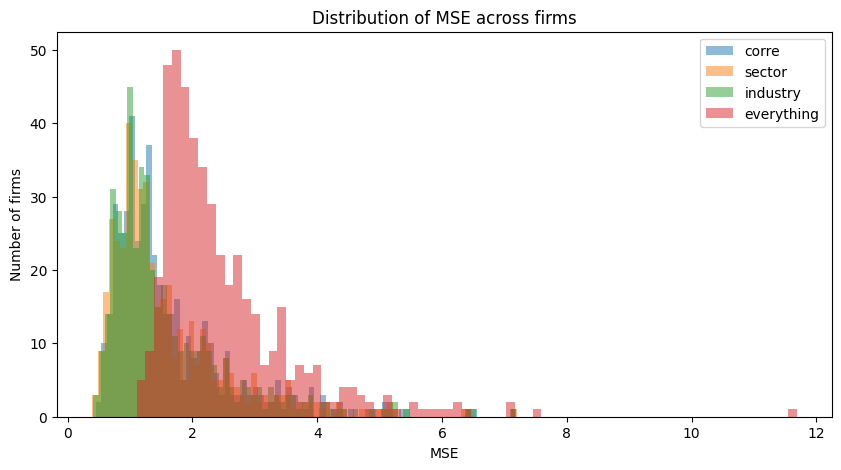

In [ ]:
# plot results that compares GAT
plt.figure(figsize=(10,5))

for key, val in MSE_dict.items():
  plt.hist(val, bins=75, alpha=0.5, label=f'{key}')

plt.legend()
plt.title("Distribution of MSE across firms")
plt.xlabel("MSE")
plt.ylabel("Number of firms")
plt.show()

/tmp/ipykernel_33645/3062524137.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(val_list, labels=label_list)


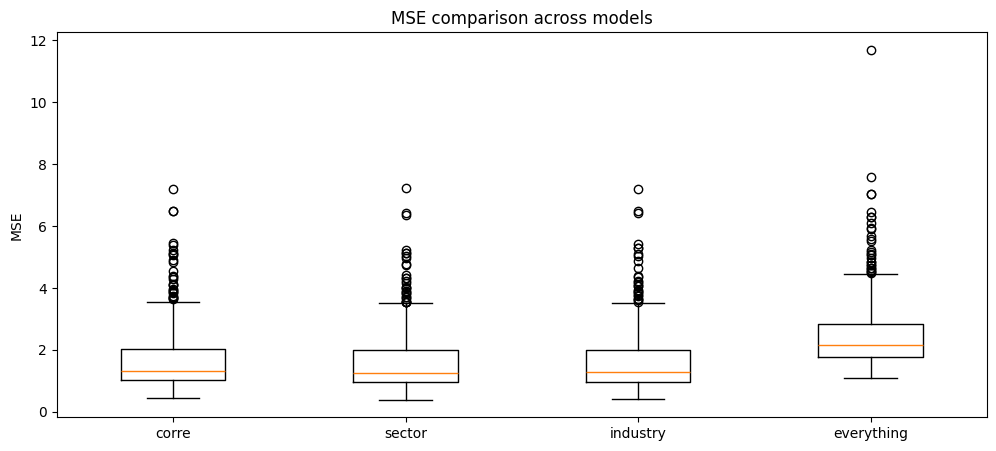

In [14]:
plt.figure(figsize=(12,5))

val_list = []
label_list = []
for key, val in MSE_dict.items():
  val_list.append(val)
  label_list.append(key)

plt.boxplot(val_list, labels=label_list)

plt.title("MSE comparison across models")
plt.ylabel("MSE")
plt.show()